#### MPAS time series plotting
- Read MPAS cells
- Specify location  
- Read MPAS and interpolate data 
- Create the figure
  
Ming Ge

In [1]:
%matplotlib inline
 
import numpy as np
import xarray as xr
from glob import glob
import os

import matplotlib.tri as tri
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 
from scipy.interpolate import griddata 

#### Read MPAS Cells

In [2]:
dir_data = '/Users/mingge/Documents/PythiaWork/code/mpasviewer-cookbook/240km_uniform/'
flnm_ini = dir_data + 'x1.10242.init.nc'
ds_i = xr.open_dataset(flnm_ini)
ds_i = ds_i.squeeze()

# Convert to degrees from radians
ds_i["lonCell"] = np.degrees(ds_i.lonCell)
ds_i["latCell"] = np.degrees(ds_i.latCell)

# For Global tripcolor plot
# Add cyclic point before computing the triangulation
ds_i["lonCell"] = ((ds_i["lonCell"] + 180) % 360) - 180

# MPAS data point coordinates.
points = np.array([ds_i["lonCell"].values , ds_i["latCell"].values]).transpose()

triang = tri.Triangulation(ds_i.lonCell, ds_i.latCell)

#### Specify the location 

In [3]:
# # Create the start point and end point for the cross section
# Points at which to interpolate data.
lat_pt, lon_pt = (39,-110) 

##### Read MPAS data  

In [4]:
pattern = os.path.join(dir_data, "diag.2014-*.00.00.nc")
files = sorted(glob(pattern))

# the variable to be interpolated 
var_s = 't2m'

data_1d = np.empty((len(files)))

for nn in np.arange(len(files)):
    flnm = files[nn]
    ds = xr.open_dataset(flnm)
    ds = ds.squeeze()
    t2 = ds[var_s]
    data_1d[nn] = griddata(points, t2.values, (lon_pt, lat_pt), method='nearest')

#### Time series plotting

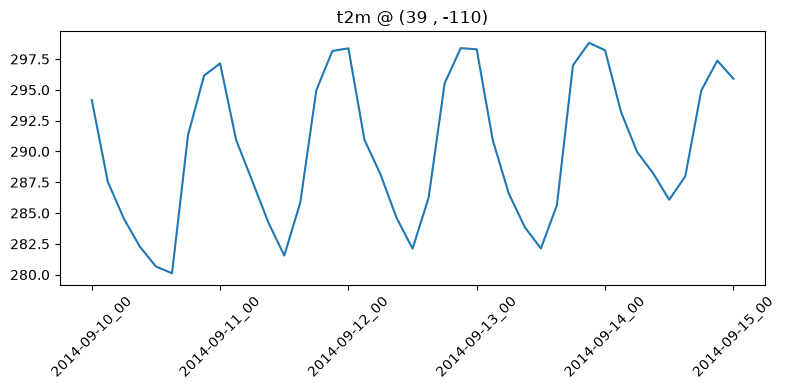

In [10]:
import pandas as pd
from pathlib import Path 
datetime = pd.date_range('2014-09-10 00', periods=len(files),  freq='3h')

datetime = pd.date_range(
    start='2014-09-10 00:00',
    end='2014-09-15 00:00',
    freq='3h'
)

#df.plot(title=' T2m @(39, -110)');
df = pd.DataFrame(
    data=data_1d,
    index=datetime,
    columns=['t2m']
)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(df.index, df['t2m'])

ticks = df.index[::8]  # every 8th timestamp

ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%m-%d_%H')
)
# Add title
ax.set_title(var_s + ' @ (' + str(lat_pt) + ' , ' + str(lon_pt) + ')')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()